# Markov Random Field (MRF) / Markov Network in Python

Clean implementation with Gibbs sampling. Fixed version — no undefined variables.

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)

In [9]:
class MarkovNetwork:
    def __init__(self):
        self.graph = nx.Graph()
        self.node_potentials = {}
        self.edge_potentials = {}

    def add_node(self, node, states, potential=None):
        self.graph.add_node(node)
        self.graph.nodes[node]['states'] = list(states)
        if potential is None:
            potential = np.ones(len(states))
        self.node_potentials[node] = np.array(potential, dtype=float)

    def add_edge(self, u, v, potential=None):
        self.graph.add_edge(u, v)
        su = len(self.graph.nodes[u]['states'])
        sv = len(self.graph.nodes[v]['states'])
        if potential is None:
            potential = np.ones((su, sv))
        pot = np.array(potential, dtype=float)
        self.edge_potentials[(u, v)] = pot
        self.edge_potentials[(v, u)] = pot.T

    def gibbs_sample(self, n_iter=1000, burn_in=200):
        nodes = list(self.graph.nodes)
        state = {n: np.random.choice(self.graph.nodes[n]['states']) for n in nodes}
        samples = []
        for t in range(n_iter):
            for n in nodes:
                states = self.graph.nodes[n]['states']
                probs = []
                for s in states:
                    p = self.node_potentials[n][states.index(s)]
                    for nb in self.graph.neighbors(n):
                        iu = states.index(s)
                        iv = self.graph.nodes[nb]['states'].index(state[nb])
                        p *= self.edge_potentials[(n, nb)][iu, iv]
                    probs.append(p)
                probs = np.array(probs)
                probs = probs / probs.sum()  # normalize
                state[n] = np.random.choice(states, p=probs)
            if t >= burn_in:
                samples.append(state.copy())
        return samples

## Example 1: 3-node chain

In [10]:
mrf = MarkovNetwork()
for node in ['A','B','C']:
    mrf.add_node(node, states=[0,1])

edge_pot = np.array([[2.0, 1.0],[1.0, 2.0]])  # prefer same
mrf.add_edge('A','B', edge_pot)
mrf.add_edge('B','C', edge_pot)

samples = mrf.gibbs_sample(n_iter=2000, burn_in=500)
p_b1 = np.mean([s['B']==1 for s in samples])
print(f"P(B=1) ≈ {p_b1:.3f}")

P(B=1) ≈ 0.503


## Example 2: Ising grid for denoising

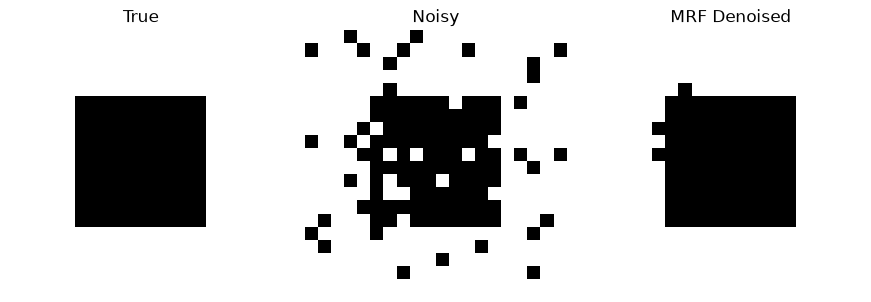

In [11]:
def build_ising_grid(observed, beta=0.8, eta=1.5):
    h,w = observed.shape
    mrf = MarkovNetwork()
    for i in range(h):
        for j in range(w):
            obs = observed[i,j]
            # states [-1, +1]
            pot = [np.exp(-eta*obs), np.exp(eta*obs)]
            mrf.add_node((i,j), states=[-1,1], potential=pot)
    edge_pot = np.array([[np.exp(beta), np.exp(-beta)],[np.exp(-beta), np.exp(beta)]])
    for i in range(h):
        for j in range(w):
            if i+1 < h: mrf.add_edge((i,j),(i+1,j), edge_pot)
            if j+1 < w: mrf.add_edge((i,j),(i,j+1), edge_pot)
    return mrf

true_img = np.ones((20,20)); true_img[5:15,5:15] = -1
noisy = true_img * np.random.choice([-1,1], size=true_img.shape, p=[0.1,0.9])

mrf_grid = build_ising_grid(noisy)
samples = mrf_grid.gibbs_sample(n_iter=300, burn_in=100)

denoised = np.zeros_like(noisy)
for i in range(noisy.shape[0]):
    for j in range(noisy.shape[1]):
        vals = [s[(i,j)] for s in samples]
        denoised[i,j] = 1 if np.mean(vals)>0 else -1

plt.figure(figsize=(9,3))
for k,img,title in zip([1,2,3],[true_img,noisy,denoised],['True','Noisy','MRF Denoised']):
    plt.subplot(1,3,k); plt.imshow(img, cmap='gray'); plt.title(title); plt.axis('off')
plt.tight_layout(); plt.show()